<br/>

<div align="center">
<span style="font-size: 2.5em;">Coverage Test Validation</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Evaluating empirical coverage and calibration of neural network posteriors</span>
</div>

## Overview

This notebook tests whether neural network posteriors are **properly calibrated** using coverage tests. We compare empirical coverage (fraction of samples where true parameters lie within a credible region) to nominal coverage levels.

### Key Concepts

- **Coverage Test**: For credible regions at nominal levels (e.g., 68%, 90%), check if true parameters are contained at the expected frequency
- **Calibration**: A well-calibrated posterior maintains empirical coverage ≈ nominal coverage across all confidence levels
- **Necessary but Not Sufficient**: Good coverage is required but doesn't guarantee accurate or precise posteriors

We evaluate coverage on both validation and test sets for consistency.

In [ ]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os, sys
desired_root_name = "xenon-sbi"  
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import torch

from configs.config import load_model, PARAM_RANGES
from utils.processing import load_matching_pairs
from performances.metrics import coverage_test, plot_coverage

## Model Configuration

Specify the model architecture, halo assumption, and data parameters for evaluation.

In [2]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "ntothighest"          
halo      = "default"       
datatag   = "low"
n_train   = 300_000
top_k     = 10              

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Data and Model Loading

Load the trained model and prepare dataloaders for evaluation.

In [3]:
# =============================
# LOAD MODEL AND CHECKPOINT
# =============================

DATAPATH = f"data/datasets/wimpy/{halo}/wimpy_n{n_train}_{datatag}_{halo}.pt"
MODELPATH = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"

model, ckpt = load_model(MODELPATH, modelname, print_arch=False)
print(f"Loading model from:\n{MODELPATH}\n")

Loading model from:
models/wimpy/default/ntothighest_n300000_low_default.pt



In [4]:
# =====================================
# LOAD TEST AND/OR VALIDATION DATA
# =====================================

X_test, T_test = load_matching_pairs(halo_choice=halo, n_train=n_train, datatag=datatag, split="test")
X_val, T_val = load_matching_pairs(halo_choice=halo, n_train=n_train, datatag=datatag, split="val")


Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt



## Coverage Test: Test Set

Evaluate coverage on the test set using 1000 samples across 50 credibility levels.

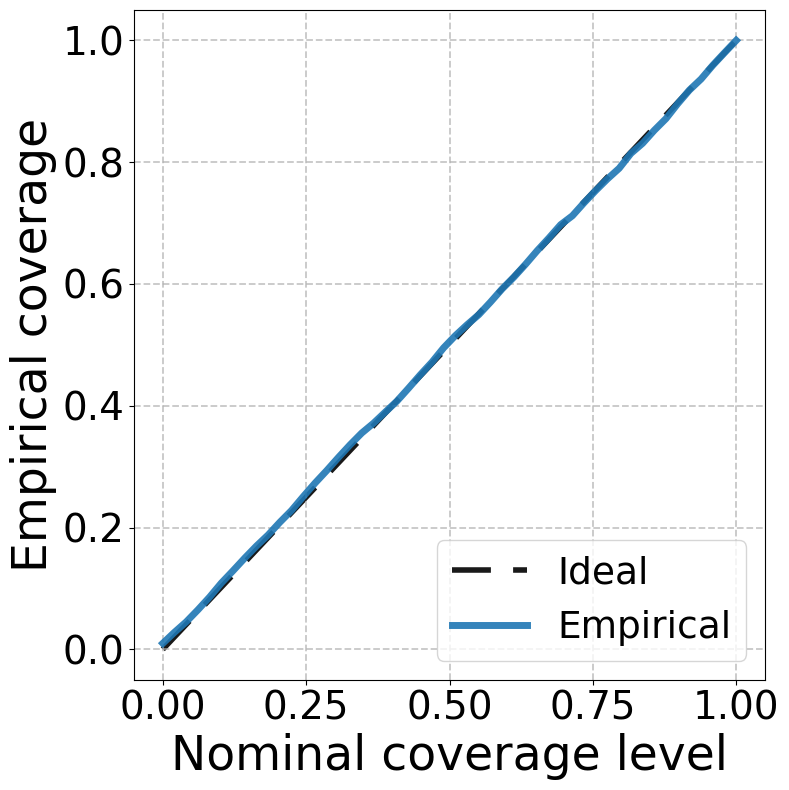

Coverage Test Scores on Test Set:
########################################
      score_abs:    0.004
      score_signed: 0.002
########################################


In [ ]:
coverages_test, score_abs_test, score_signed_test = coverage_test(
    model,
    X_test,
    T_test,
    logm_range,
    logcp_range,
    posteriorbins=100,
    device=device,
    n_samples=5000,
    levels = np.linspace(0, 1, 50)
)

plot_coverage(
    coverages_test,
    #save_path=f"figures/...",
)

print("Coverage Test Scores on Test Set:")
print("########################################")
print(f"      score_abs:    {score_abs_test:.3f}")
print(f"      score_signed: {score_signed_test:.3f}")
print("########################################")


## Summary

The distinction between validation and test sets is largely arbitrary here, as hyperparameter optimization is not involved. Both sets are included for consistency with standard ML practice and enable validation of reproducibility across splits. We find that the coverages of the models are excellent for the **low** dataset, but are slightly worse for the **mid** and **high** datasets. This is mainly because with higher couplings, the spectra contain (much) more events and the posteriors thus become significantly smaller, making it harder for the NN to accurately learn the distributions. 